<a href="https://colab.research.google.com/github/cisembayer/Data-Science-Final-Project/blob/main/DS_%26_Business_Umesh_Contribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.listdir("/content")

['.config', 'bitcoinity_cleaned.csv', 'sample_data']

In [ ]:
import os

os.listdir("/content")


['.config', 'bitcoinity_cleaned.csv', 'sample_data']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Bitcoinity data
btc_df = pd.read_csv("/content/bitcoinity_cleaned.csv")

# Inspect columns
btc_df.head(), btc_df.columns.tolist()

(         Time     bitstamp    cex.io     coinbase       exmo       kraken  \
 0  2025-06-02    63.676077  1.827838    75.264516   9.823327    65.772330   
 1  2025-06-09  1017.704045  1.827838  1479.039509  73.279674   994.456062   
 2  2025-06-16   998.468447  0.000470  1641.574995  73.220186  1217.290954   
 3  2025-06-23   922.483559  1.827838  1250.520250  73.396869  1014.335795   
 4  2025-06-30   679.815773  1.827838  1187.202267  73.219486   871.376800   
 
     paymium  
 0  0.051803  
 1  7.180464  
 2  8.780651  
 3  5.225518  
 4  9.966818  ,
 ['Time', 'bitstamp', 'cex.io', 'coinbase', 'exmo', 'kraken', 'paymium'])

In [ ]:
import pandas as pd

btc_df = pd.read_csv("/content/bitcoinity_cleaned.csv")

# PRINT EXACT COLUMN NAMES
print(btc_df.columns.tolist())

['Time', 'bitstamp', 'cex.io', 'coinbase', 'exmo', 'kraken', 'paymium']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

btc_df = pd.read_csv("/content/bitcoinity_cleaned.csv")

btc_df.columns = btc_df.columns.str.strip().str.lower()
btc_df.head(), btc_df.columns.tolist()

(         time     bitstamp    cex.io     coinbase       exmo       kraken  \
 0  2025-06-02    63.676077  1.827838    75.264516   9.823327    65.772330   
 1  2025-06-09  1017.704045  1.827838  1479.039509  73.279674   994.456062   
 2  2025-06-16   998.468447  0.000470  1641.574995  73.220186  1217.290954   
 3  2025-06-23   922.483559  1.827838  1250.520250  73.396869  1014.335795   
 4  2025-06-30   679.815773  1.827838  1187.202267  73.219486   871.376800   
 
     paymium  
 0  0.051803  
 1  7.180464  
 2  8.780651  
 3  5.225518  
 4  9.966818  ,
 ['time', 'bitstamp', 'cex.io', 'coinbase', 'exmo', 'kraken', 'paymium'])

In [ ]:
btc_df["time"] = pd.to_datetime(btc_df["time"])
btc_df["year"] = btc_df["time"].dt.year

In [ ]:
# Melt exchange columns into one BTC volume column
btc_long = btc_df.melt(
    id_vars=["time", "year"],
    var_name="exchange",
    value_name="volume_btc"
)

btc_long.head()

,time,year,exchange,volume_btc
0,2025-06-02,2025,bitstamp,63.676077
1,2025-06-09,2025,bitstamp,1017.704045
2,2025-06-16,2025,bitstamp,998.468447
3,2025-06-23,2025,bitstamp,922.483559
4,2025-06-30,2025,bitstamp,679.815773


In [ ]:
btc_long = btc_long.dropna(subset=["volume_btc"])
btc_long = btc_long[btc_long["volume_btc"] > 0]

In [ ]:
usd_exchanges = ["bitstamp", "coinbase", "kraken"]
btc_long["currency_group"] = btc_long["exchange"].apply(
    lambda x: "USD" if x in usd_exchanges else "Non-USD"
)

In [ ]:
btc_summary = (
    btc_long
    .groupby(["year", "currency_group"], as_index=False)
    .agg(total_volume_btc=("volume_btc", "sum"))
)

btc_totals = btc_summary.groupby("year")["total_volume_btc"].sum().reset_index()
btc_summary = btc_summary.merge(btc_totals, on="year")

btc_summary["share_pct"] = (
    btc_summary["total_volume_btc_x"] /
    btc_summary["total_volume_btc_y"] * 100
)

btc_summary

,year,currency_group,total_volume_btc_x,total_volume_btc_y,share_pct
0,2025,Non-USD,3012.862710,108378.654184,2.779941
1,2025,USD,105365.791474,108378.654184,97.220059


In [ ]:
btc_summary = (
    btc_long
    .groupby(["year", "currency_group"], as_index=False)
    .agg(total_volume_btc=("volume_btc", "sum"))
)

btc_totals = btc_summary.groupby("year")["total_volume_btc"].sum().reset_index()
btc_summary = btc_summary.merge(btc_totals, on="year")

btc_summary["share_pct"] = (
    btc_summary["total_volume_btc_x"] /
    btc_summary["total_volume_btc_y"] * 100
)

btc_summary

,year,currency_group,total_volume_btc_x,total_volume_btc_y,share_pct
0,2025,Non-USD,3012.862710,108378.654184,2.779941
1,2025,USD,105365.791474,108378.654184,97.220059


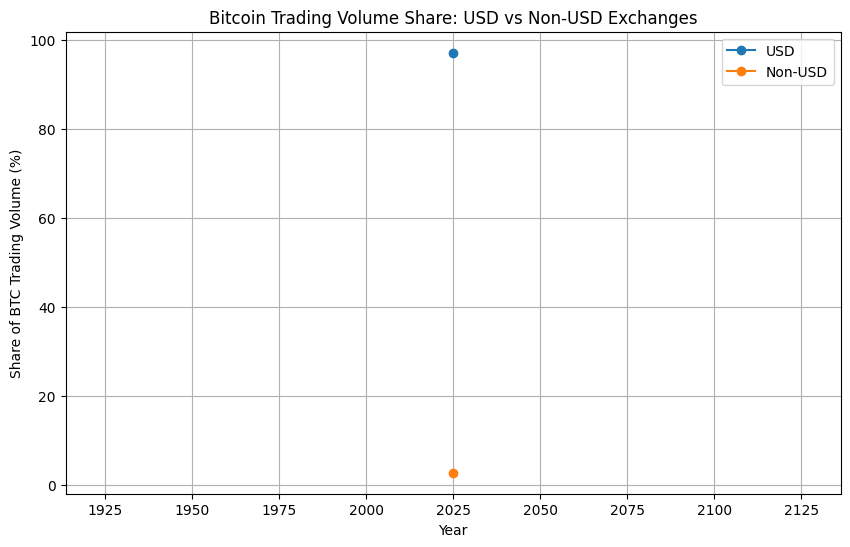

In [ ]:
plt.figure(figsize=(10,6))

for grp in ["USD", "Non-USD"]:
    subset = btc_summary[btc_summary["currency_group"] == grp]
    plt.plot(
        subset["year"],
        subset["share_pct"],
        marker="o",
        label=grp
    )

plt.title("Bitcoin Trading Volume Share: USD vs Non-USD Exchanges")
plt.xlabel("Year")
plt.ylabel("Share of BTC Trading Volume (%)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Check uploaded files
import os
os.listdir("/content")

['.config',
 'Gold_Import_TradeData_clean_final.csv',
 'crude_pertroleum_import.csv',
 'bitcoinity_cleaned.csv',
 'sample_data']

In [ ]:
import os
os.listdir("/content")


['.config',
 'Gold_Import_TradeData_clean_final.csv',
 'crude_pertroleum_import.csv',
 'bitcoinity_cleaned.csv',
 'sample_data']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

btc_df  = pd.read_csv("/content/bitcoinity_cleaned.csv")
gold_df = pd.read_csv("/content/Gold_Import_TradeData_clean_final.csv")
oil_df  = pd.read_csv("/content/crude_pertroleum_import.csv")

print("BTC shape:", btc_df.shape)
print("Gold shape:", gold_df.shape)
print("Oil shape:", oil_df.shape)

BTC shape: (27, 7)
Gold shape: (819, 33)
Oil shape: (745, 19)


In [ ]:
gold = gold_df[
    ["refyear_clean", "reporteriso", "reporterdesc", "flowdesc", "qty", "primaryvalue"]
]

gold = gold[gold["flowdesc"] == "Import"]

BRICS = ["BRA", "RUS", "IND", "CHN", "ZAF"]
US_EU = ["USA", "DEU", "FRA", "ITA", "ESP", "NLD"]

gold["group"] = gold["reporteriso"].apply(
    lambda x: "BRICS" if x in BRICS else "US_EU" if x in US_EU else "Other"
)

In [ ]:
avg_gold = (
    gold
    .groupby(["refyear_clean", "group"], as_index=False)
    .agg(avg_gold_kg=("qty", "mean"))
)

avg_gold

,refyear_clean,group,avg_gold_kg
0,2019,BRICS,368594.096400
1,2019,Other,29388.967805
2,2019,US_EU,53921.681667
3,2020,BRICS,130292.465200
4,2020,Other,31552.286047
5,2020,US_EU,171624.821333
6,2021,BRICS,380893.754800
7,2021,Other,28275.847672
8,2021,US_EU,113191.200833
9,2022,BRICS,517554.602000


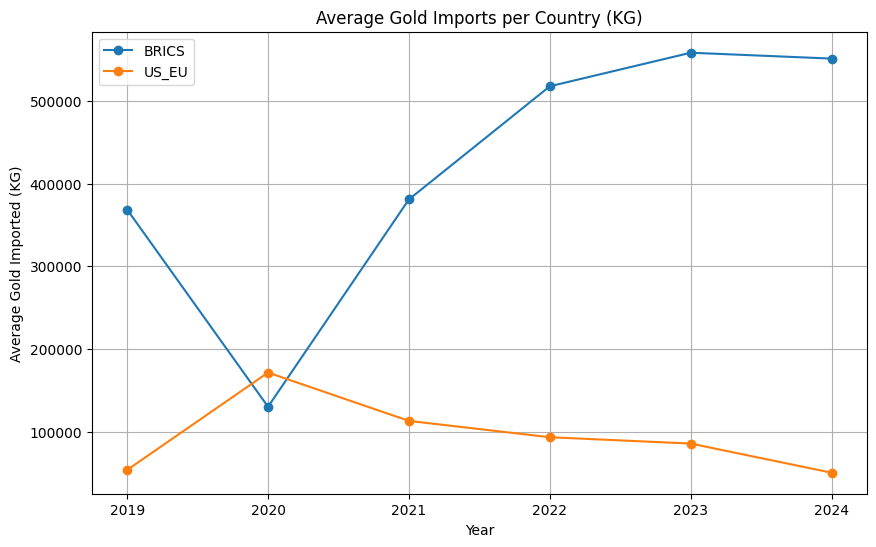

In [ ]:
plt.figure(figsize=(10,6))

for grp in ["BRICS", "US_EU"]:
    subset = avg_gold[avg_gold["group"] == grp]
    plt.plot(subset["refyear_clean"], subset["avg_gold_kg"], marker="o", label=grp)

plt.title("Average Gold Imports per Country (KG)")
plt.xlabel("Year")
plt.ylabel("Average Gold Imported (KG)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gold_2425 = gold[gold["refyear_clean"].isin([2024, 2025])]

top_gold_country = (
    gold_2425
    .groupby("reporterdesc", as_index=False)
    .agg(total_gold_kg=("qty", "sum"))
    .sort_values("total_gold_kg", ascending=False)
)

top_gold_country.head(10)

,reporterdesc,total_gold_kg
25,China,1380568.402
117,United Kingdom,991983.722
26,"China, Hong Kong SAR",885882.000
53,India,806302.573
103,Singapore,316144.849
113,Türkiye,231784.263
114,USA,218524.046
21,Canada,211533.604
5,Australia,98852.105
4,Armenia,85175.006


In [ ]:
gold_2425 = gold[gold["refyear_clean"].isin([2024, 2025])]

top_gold_country = (
    gold_2425
    .groupby("reporterdesc", as_index=False)
    .agg(total_gold_kg=("qty", "sum"))
    .sort_values("total_gold_kg", ascending=False)
)

top_gold_country.head(10)

,reporterdesc,total_gold_kg
25,China,1380568.402
117,United Kingdom,991983.722
26,"China, Hong Kong SAR",885882.000
53,India,806302.573
103,Singapore,316144.849
113,Türkiye,231784.263
114,USA,218524.046
21,Canada,211533.604
5,Australia,98852.105
4,Armenia,85175.006


In [ ]:
top10_gold = top_gold_country.head(10)

In [ ]:
gold_2425 = gold[gold["refyear_clean"].isin([2024, 2025])]

top_gold_country = (
    gold_2425
    .groupby("reporterdesc", as_index=False)
    .agg(total_gold_kg=("qty", "sum"))
    .sort_values("total_gold_kg", ascending=False)
)

top10_gold = top_gold_country.head(10)

In [ ]:
top10_gold

,reporterdesc,total_gold_kg
25,China,1380568.402
117,United Kingdom,991983.722
26,"China, Hong Kong SAR",885882.000
53,India,806302.573
103,Singapore,316144.849
113,Türkiye,231784.263
114,USA,218524.046
21,Canada,211533.604
5,Australia,98852.105
4,Armenia,85175.006


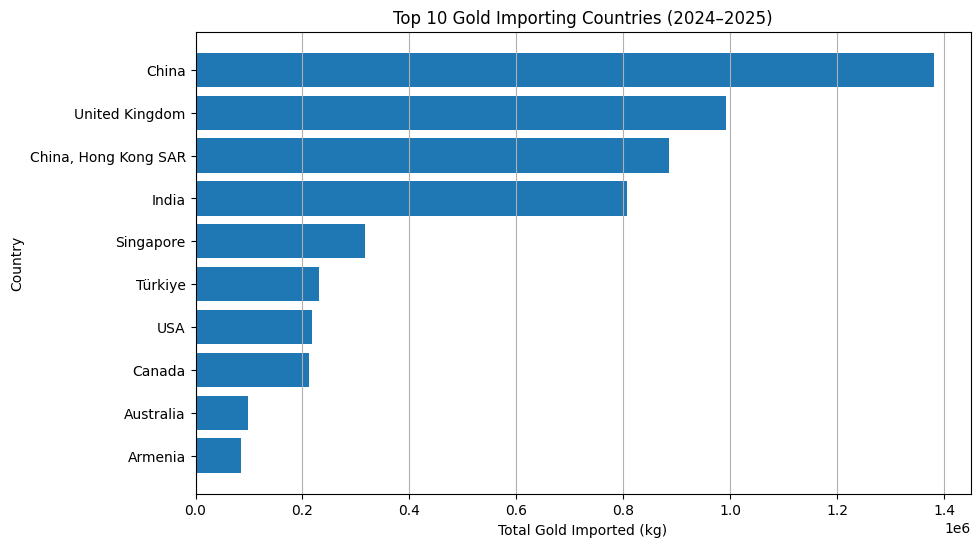

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10_gold["reporterdesc"],
    top10_gold["total_gold_kg"]
)

plt.xlabel("Total Gold Imported (kg)")
plt.ylabel("Country")
plt.title("Top 10 Gold Importing Countries (2024–2025)")

plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis="x")

plt.show()

In [ ]:
import os
os.listdir("/content")

['.config', 'sample_data']

In [ ]:
['Gold_Import_TradeData_clean_final (1).csv',
 'bitcoinity_cleaned.csv',
 'crude_pertroleum_import.csv']

['Gold_Import_TradeData_clean_final (1).csv',
 'bitcoinity_cleaned.csv',
 'crude_pertroleum_import.csv']

In [ ]:
import pandas as pd

# Load gold data
gold_df = pd.read_csv("/content/Gold_Import_TradeData_clean_final.csv")

# Keep required columns
gold = gold_df[
    ["refyear_clean", "reporteriso", "reporterdesc", "flowdesc", "qty"]
]

# Use imports only
gold = gold[gold["flowdesc"] == "Import"]

# Define country groups
BRICS = ["BRA", "RUS", "IND", "CHN", "ZAF"]
US_EU = ["USA", "DEU", "FRA", "ITA", "ESP", "NLD"]

gold["group"] = gold["reporteriso"].apply(
    lambda x: "BRICS" if x in BRICS else "US_EU" if x in US_EU else "Other"
)

In [ ]:
gold_world = (
    gold
    .groupby("refyear_clean", as_index=False)
    .agg(world_gold_kg=("qty", "sum"))
)

In [ ]:
gold_brics = (
    gold[gold["group"] == "BRICS"]
    .groupby("refyear_clean", as_index=False)
    .agg(brics_gold_kg=("qty", "sum"))
)

In [ ]:
gold_share = gold_world.merge(gold_brics, on="refyear_clean")

gold_share["brics_share_pct"] = (
    gold_share["brics_gold_kg"] / gold_share["world_gold_kg"] * 100
)

gold_share

,refyear_clean,world_gold_kg,brics_gold_kg,brics_share_pct
0,2019,5.928288e+06,1842970.482,31.087733
1,2020,5.719904e+06,651462.326,11.389393
2,2021,6.287752e+06,1904468.774,30.288548
3,2022,8.775138e+06,2070218.408,23.591861
4,2023,1.012770e+07,2232372.273,22.042247
5,2024,5.578608e+06,2204005.923,39.508167


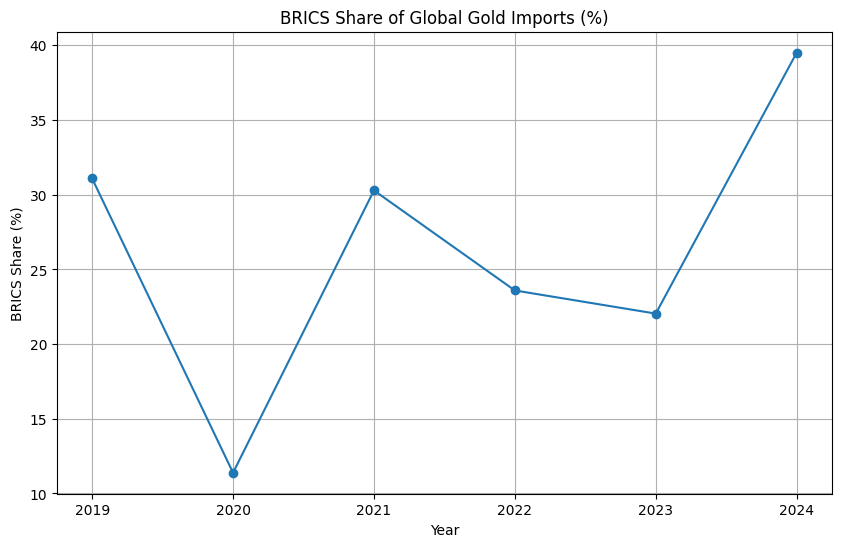

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(
    gold_share["refyear_clean"],
    gold_share["brics_share_pct"],
    marker="o"
)

plt.title("BRICS Share of Global Gold Imports (%)")
plt.xlabel("Year")
plt.ylabel("BRICS Share (%)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

oil_df = pd.read_csv("/content/crude_pertroleum_import.csv")
oil_df.head()

,refYear,reporterCode,reporterISO,reporterDesc,classificationCode,cmdCode,cmdDesc,qtyUnitCode,qtyUnitAbbr,qty,altQtyUnitCode,altQtyUnitAbbr,altQty,netWgt,grossWgt,cifvalue,fobvalue,primaryValue,legacyEstimationFlag
0,2019,4,AFG,Afghanistan,H4,2709,Crude petroleum oil,8,kg,1.188788e+08,8,kg,1.188788e+08,1.188788e+08,0.0,3.437247e+07,0.0,3.437247e+07,0
1,2019,20,AND,Andorra,H5,2709,Crude petroleum oil,8,kg,3.236850e+03,8,kg,3.236850e+03,3.236850e+03,0.0,1.207124e+04,0.0,1.207124e+04,0
2,2019,24,AGO,Angola,H5,2709,Crude petroleum oil,8,kg,1.804062e+03,8,kg,1.804062e+03,1.804062e+03,0.0,1.761858e+04,0.0,1.761858e+04,0
3,2019,28,ATG,Antigua and Barbuda,H3,2709,Crude petroleum oil,8,kg,1.356000e+02,8,kg,1.356000e+02,1.356000e+02,0.0,5.807370e+02,0.0,5.807370e+02,0
4,2019,31,AZE,Azerbaijan,H5,2709,Crude petroleum oil,-1,kg,0.000000e+00,-1,kg,0.000000e+00,6.832030e+06,0.0,1.913474e+08,0.0,1.913474e+08,0


In [ ]:
oil_df["refYear"] = oil_df["refYear"].astype(int)

oil_2425 = oil_df[oil_df["refYear"].isin([2024, 2025])]

In [ ]:
oil_country_growth = (
    oil_2425
    .groupby("reporterDesc", as_index=False)
    .agg(total_oil_qty=("qty", "sum"))
    .sort_values("total_oil_qty", ascending=False)
)

oil_country_growth.head(10)

,reporterDesc,total_oil_qty
20,China,5.532319e+11
94,USA,3.756571e+11
44,India,2.417502e+11
92,Thailand,1.777618e+11
78,Rep. of Korea,1.371800e+11
49,Japan,1.149586e+11
66,Netherlands,7.921795e+10
37,Germany,7.853696e+10
48,Italy,4.766855e+10
35,France,4.702013e+10


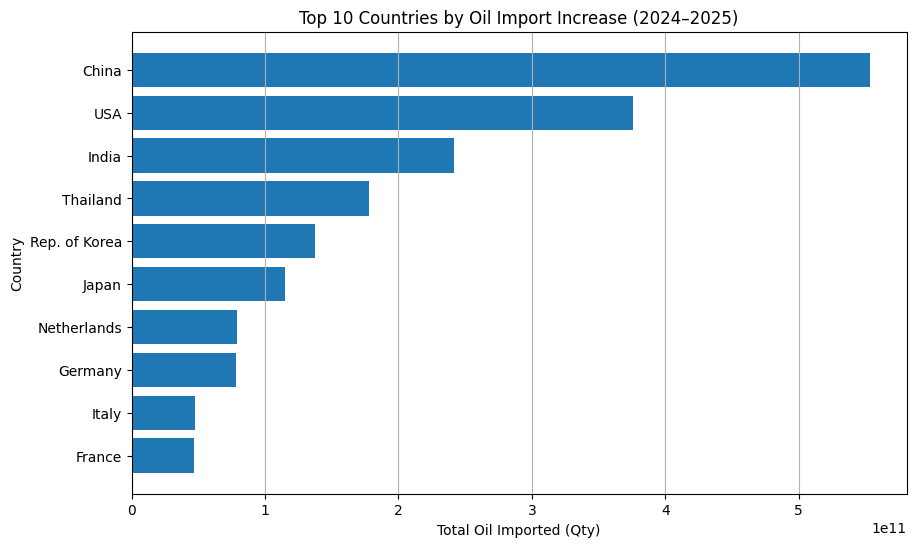

In [ ]:
import matplotlib.pyplot as plt

top10_oil = oil_country_growth.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_oil["reporterDesc"], top10_oil["total_oil_qty"])
plt.xlabel("Total Oil Imported (Qty)")
plt.ylabel("Country")
plt.title("Top 10 Countries by Oil Import Increase (2024–2025)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [ ]:
btc_df = pd.read_csv("/content/bitcoinity_cleaned.csv")
btc_df.head()

,Time,bitstamp,cex.io,coinbase,exmo,kraken,paymium
0,2025-06-02,63.676077,1.827838,75.264516,9.823327,65.772330,0.051803
1,2025-06-09,1017.704045,1.827838,1479.039509,73.279674,994.456062,7.180464
2,2025-06-16,998.468447,0.000470,1641.574995,73.220186,1217.290954,8.780651
3,2025-06-23,922.483559,1.827838,1250.520250,73.396869,1014.335795,5.225518
4,2025-06-30,679.815773,1.827838,1187.202267,73.219486,871.376800,9.966818


In [ ]:
btc_df.columns = btc_df.columns.str.lower()

btc_df["time"] = pd.to_datetime(btc_df["time"])
btc_df["year"] = btc_df["time"].dt.year

btc_long = btc_df.melt(
    id_vars=["time", "year"],
    var_name="exchange",
    value_name="btc_volume"
)

btc_long = btc_long.dropna(subset=["btc_volume"])
btc_long = btc_long[btc_long["btc_volume"] > 0]

In [ ]:
btc_2425 = btc_long[btc_long["year"].isin([2024, 2025])]

In [ ]:
btc_exchange_growth = (
    btc_2425
    .groupby("exchange", as_index=False)
    .agg(total_btc_volume=("btc_volume", "sum"))
    .sort_values("total_btc_volume", ascending=False)
)

btc_exchange_growth.head(10)

,exchange,total_btc_volume
2,coinbase,37002.152278
4,kraken,36581.145636
0,bitstamp,31782.493561
3,exmo,2649.040376
5,paymium,315.373831
1,cex.io,48.448503


In [ ]:
top10_btc = btc_exchange_growth.head(10)

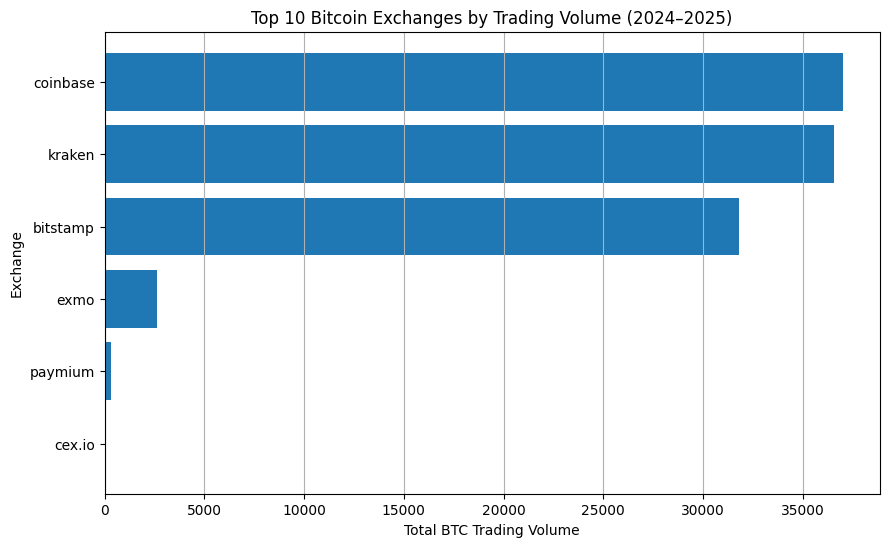

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10_btc["exchange"],
    top10_btc["total_btc_volume"]
)

plt.xlabel("Total BTC Trading Volume")
plt.ylabel("Exchange")
plt.title("Top 10 Bitcoin Exchanges by Trading Volume (2024–2025)")

plt.gca().invert_yaxis()  # Highest volume at top
plt.grid(axis="x")

plt.show()

/tmp/ipython-input-881196322.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_price["gold_price_usd_per_kg"] = (


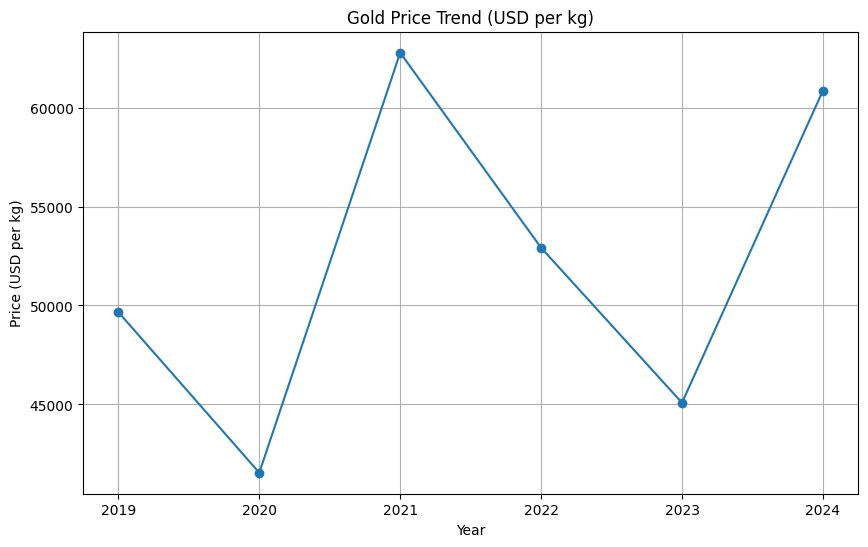

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric
gold_df["refyear_clean"] = gold_df["refyear_clean"].astype(int)

# Remove zero quantities
gold_price = gold_df[(gold_df["qty"] > 0) & (gold_df["primaryvalue"] > 0)]

# Compute unit price (USD per kg)
gold_price["gold_price_usd_per_kg"] = (
    gold_price["primaryvalue"] / gold_price["qty"]
)

# Yearly average price
gold_price_trend = (
    gold_price
    .groupby("refyear_clean", as_index=False)
    .agg(avg_gold_price=("gold_price_usd_per_kg", "mean"))
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(
    gold_price_trend["refyear_clean"],
    gold_price_trend["avg_gold_price"],
    marker="o"
)

plt.title("Gold Price Trend (USD per kg)")
plt.xlabel("Year")
plt.ylabel("Price (USD per kg)")
plt.grid(True)
plt.show()

/tmp/ipython-input-2911716208.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oil_price["oil_price_usd"] = (


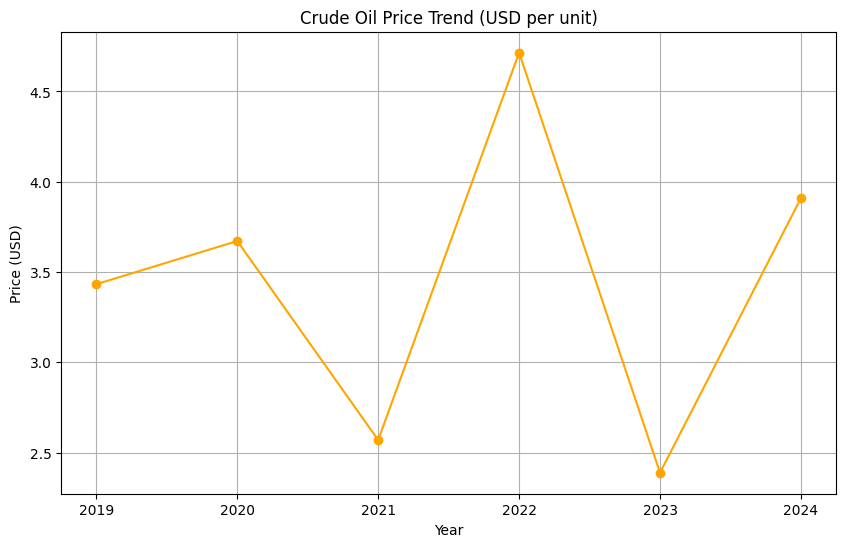

In [ ]:
# Ensure numeric
oil_df["refYear"] = oil_df["refYear"].astype(int)

# Remove zero quantities
oil_price = oil_df[(oil_df["qty"] > 0) & (oil_df["primaryValue"] > 0)]

# Compute unit price
oil_price["oil_price_usd"] = (
    oil_price["primaryValue"] / oil_price["qty"]
)

# Yearly average oil price
oil_price_trend = (
    oil_price
    .groupby("refYear", as_index=False)
    .agg(avg_oil_price=("oil_price_usd", "mean"))
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(
    oil_price_trend["refYear"],
    oil_price_trend["avg_oil_price"],
    marker="o",
    color="orange"
)

plt.title("Crude Oil Price Trend (USD per unit)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# GOLD: unit value = USD per kg
gold_price = gold_df[
    (gold_df["qty"] > 0) & (gold_df["primaryvalue"] > 0)
].copy()

gold_price["gold_unit_value"] = gold_price["primaryvalue"] / gold_price["qty"]

gold_trend = (
    gold_price
    .groupby("refyear_clean", as_index=False)
    .agg(gold_unit_value=("gold_unit_value", "mean"))
)

gold_trend.rename(columns={"refyear_clean": "year"}, inplace=True)

In [ ]:
# OIL: unit value = USD per unit
oil_price = oil_df[
    (oil_df["qty"] > 0) & (oil_df["primaryValue"] > 0)
].copy()

oil_price["oil_unit_value"] = oil_price["primaryValue"] / oil_price["qty"]

oil_trend = (
    oil_price
    .groupby("refYear", as_index=False)
    .agg(oil_unit_value=("oil_unit_value", "mean"))
)

oil_trend.rename(columns={"refYear": "year"}, inplace=True)

In [ ]:
# BTC: trading activity trend
btc_df.columns = btc_df.columns.str.lower()

btc_df["time"] = pd.to_datetime(btc_df["time"])
btc_df["year"] = btc_df["time"].dt.year

btc_long = btc_df.melt(
    id_vars=["time", "year"],
    var_name="exchange",
    value_name="btc_volume"
)

btc_long = btc_long.dropna(subset=["btc_volume"])
btc_long = btc_long[btc_long["btc_volume"] > 0]

btc_trend = (
    btc_long
    .groupby("year", as_index=False)
    .agg(btc_activity=("btc_volume", "sum"))
)

In [ ]:
print("Gold years:", gold_trend["year"].min(), "-", gold_trend["year"].max())
print("Oil years:", oil_trend["year"].min(), "-", oil_trend["year"].max())
print("BTC years:", btc_trend["year"].min(), "-", btc_trend["year"].max())

Gold years: 2019 - 2024
Oil years: 2019 - 2024
BTC years: 2025 - 2025


In [ ]:
combined = (
    gold_trend
    .merge(oil_trend, on="year", how="outer")
    .merge(btc_trend, on="year", how="outer")
    .sort_values("year")
)

combined

,year,gold_unit_value,oil_unit_value,btc_activity
0,2019,49664.142486,3.432510,NaN
1,2020,41547.568209,3.671472,NaN
2,2021,62775.686176,2.569405,NaN
3,2022,52917.851306,4.714415,NaN
4,2023,45083.257930,2.388272,NaN
5,2024,60863.571950,3.909098,NaN
6,2025,NaN,NaN,108378.654184


In [ ]:
combined = combined.fillna(method="ffill").fillna(method="bfill")

/tmp/ipython-input-4092574747.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined = combined.fillna(method="ffill").fillna(method="bfill")


In [ ]:
for col in ["gold_unit_value", "oil_unit_value", "btc_activity"]:
    base = combined[col].dropna().iloc[0]
    combined[col] = combined[col] / base * 100

combined

,year,gold_unit_value,oil_unit_value,btc_activity
0,2019,100.000000,100.000000,100.0
1,2020,83.657074,106.961718,100.0
2,2021,126.400423,74.854999,100.0
3,2022,106.551425,137.345996,100.0
4,2023,90.776274,69.578016,100.0
5,2024,122.550333,113.884549,100.0
6,2025,122.550333,113.884549,100.0


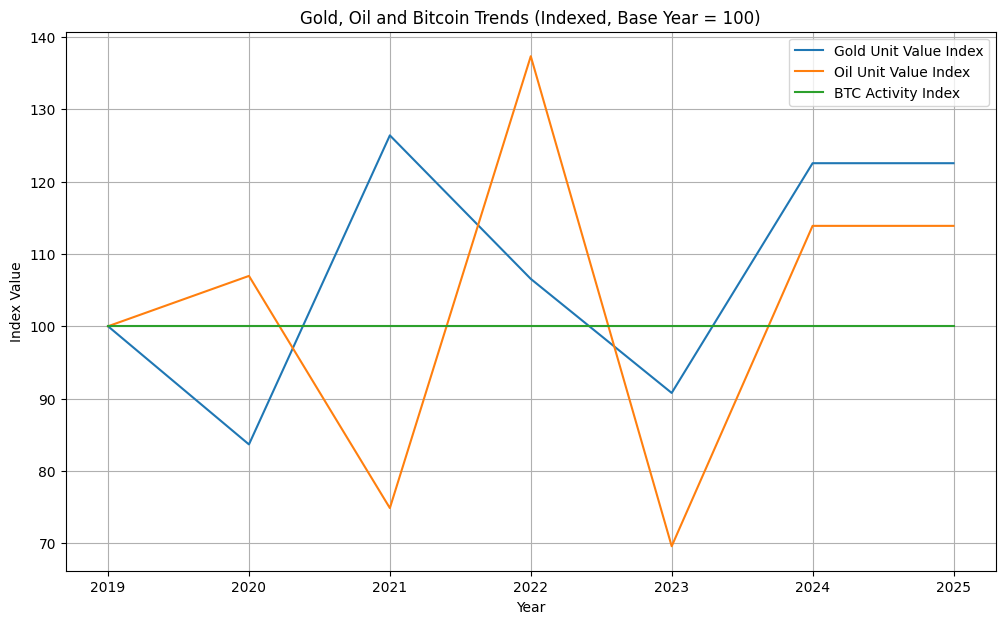

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

plt.plot(combined["year"], combined["gold_unit_value"], label="Gold Unit Value Index")
plt.plot(combined["year"], combined["oil_unit_value"], label="Oil Unit Value Index")
plt.plot(combined["year"], combined["btc_activity"], label="BTC Activity Index")

plt.title("Gold, Oil and Bitcoin Trends (Indexed, Base Year = 100)")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
combined_table = combined[[
    "year",
    "gold_unit_value",
    "oil_unit_value",
    "btc_activity"
]].copy()

# Round values for readability
combined_table[[
    "gold_unit_value",
    "oil_unit_value",
    "btc_activity"
]] = combined_table[[
    "gold_unit_value",
    "oil_unit_value",
    "btc_activity"
]].round(2)

combined_table

,year,gold_unit_value,oil_unit_value,btc_activity
0,2019,100.00,100.00,100.0
1,2020,83.66,106.96,100.0
2,2021,126.40,74.85,100.0
3,2022,106.55,137.35,100.0
4,2023,90.78,69.58,100.0
5,2024,122.55,113.88,100.0
6,2025,122.55,113.88,100.0


In [ ]:
# Filter BRICS gold data
brics_gold = gold[gold["group"] == "BRICS"]

# Aggregate yearly total
brics_yearly = (
    brics_gold
    .groupby("refyear_clean", as_index=False)
    .agg(total_gold_kg=("qty", "sum"))
)

brics_yearly

,refyear_clean,total_gold_kg
0,2019,1842970.482
1,2020,651462.326
2,2021,1904468.774
3,2022,2070218.408
4,2023,2232372.273
5,2024,2204005.923


In [ ]:
start_year = 2021
end_year = brics_yearly["refyear_clean"].max()

# Extract start and end totals
start_value = brics_yearly.loc[
    brics_yearly["refyear_clean"] == start_year, "total_gold_kg"
].values[0]

end_value = brics_yearly.loc[
    brics_yearly["refyear_clean"] == end_year, "total_gold_kg"
].values[0]

start_value, end_value, start_year, end_year

(np.float64(1904468.774), np.float64(2204005.923), 2021, 2024)

In [ ]:
# Number of periods
years = end_year - start_year

# CAGR formula
cagr = (end_value / start_value) ** (1 / years) - 1

cagr

np.float64(0.04989604648989343)

In [ ]:
print(f"CAGR of BRICS gold reserves (2021–{end_year}): {cagr * 100:.2f}%")

CAGR of BRICS gold reserves (2021–2024): 4.99%
